0. 环境导入

In [1]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


2.1 理论计算题

1）无激活的单隐层 MLP 等价于单层网络
$$
h = W_1 x + b_1
$$

$$
o = W_2 h + b_2
$$

$$
o = W_2 (W_1 x + b_1) + b_2
= (W_2 W_1) x + (W_2 b_1 + b_2)
$$

$$
W' = W_2 W_1,\quad b' = W_2 b_1 + b_2
$$

$$
o = W' x + b'
$$

2）Sigmoid、tanh 及其导数
$$
\sigma(x) = \frac{1}{1+e^{-x}}
$$

$$
\sigma'(x) = \sigma(x)\,(1-\sigma(x))
$$

$$
\tanh(x) = \frac{e^{x}-e^{-x}}{e^{x}+e^{-x}}
$$

$$
\tanh'(x) = 1 - \tanh^2(x)
$$

2.2 单隐藏层 MLP（从零实现，Fashion-MNIST）

2.2.1 数据加载

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

# 展平 28x28 → 784
X, y = next(iter(train_loader))
print(X.shape, y.shape)

Using downloaded and verified file: ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz
Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw

Using downloaded and verified file: ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz
Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:02<00:00, 2.15MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.13MB/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

torch.Size([128, 1, 28, 28]) torch.Size([128])


2.2.2 参数初始化（正态分布）

In [4]:
# 维度：输入784，隐藏层256，输出10
n_in, n_hid, n_out = 784, 256, 10

# 正态初始化
W1 = torch.randn(n_in, n_hid, device=device) * 0.01
b1 = torch.zeros(n_hid, device=device)
W2 = torch.randn(n_hid, n_out, device=device) * 0.01
b2 = torch.zeros(n_out, device=device)

params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

2.2.3 ReLU、Softmax + 交叉熵

In [5]:
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=device))

def softmax(x):
    # 数值稳定
    max_x = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - max_x)
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

def cross_entropy(logits, labels):
    # logits: (B,10), labels: (B,)
    probs = softmax(logits)
    one_hot = torch.zeros_like(probs)
    one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
    return -torch.mean(torch.sum(one_hot * torch.log(probs + 1e-8), dim=1))

2.2.4 前向、训练循环（Mini-batch SGD）

Epoch 1, Loss: 0.6477
Epoch 2, Loss: 0.4393
Epoch 3, Loss: 0.3945
Epoch 4, Loss: 0.3650
Epoch 5, Loss: 0.3462


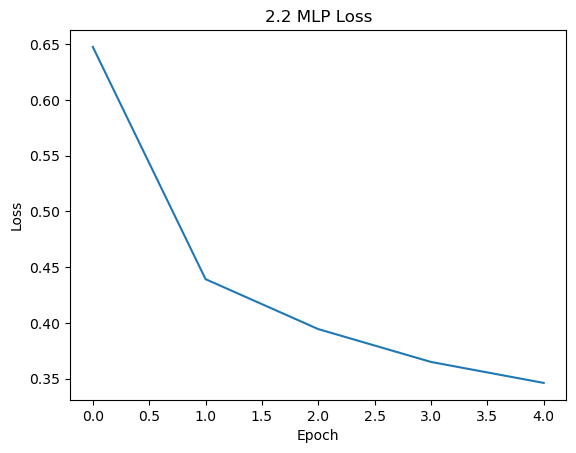

In [6]:
def forward(x):
    # x: (B,1,28,28) → (B,784)
    x = x.view(x.shape[0], -1)
    h = relu(x @ W1 + b1)
    logits = h @ W2 + b2
    return logits

def sgd_step(params, lr):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()

# 训练
lr = 0.1
epochs = 5
train_losses = []

for epoch in range(epochs):
    total_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        logits = forward(X)
        loss = cross_entropy(logits, y)
        loss.backward()
        sgd_step(params, lr)
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# 绘图
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2.2 MLP Loss")
plt.show()

3.1 理论计算题

1）过拟合、欠拟合、训练误差、泛化误差
$$
\text{TrainErr} = \frac{1}{N}\sum_{i=1}^N L(y_i,\hat y_i)
$$

$$
\text{GenErr} = \mathbb E_{(x,y)\sim P}[L(y,f(x))]
$$

2）K 折交叉验证步骤
$$
E_{\text{cv}} = \frac{1}{K}\sum_{k=1}^K E_k
$$

3.2 权重衰减（L2 正则）+ Dropout

3.2.1 权重衰减 SGD

In [7]:
def sgd_weight_decay(params, lr, wd):
    with torch.no_grad():
        for p in params:
            p *= (1 - lr * wd)   # 权重衰减
            p -= lr * p.grad
            p.grad.zero_()

3.2.2 Dropout 从零实现

In [8]:
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    # 掩码：保留概率 1-dropout
    mask = torch.rand_like(X) > dropout
    X = X * mask / (1 - dropout)  # 缩放
    return X

3.2.3 带正则的 MLP

[无正则] Epoch 1 | Train Loss: 0.6424 | Val Loss: 0.5062
[无正则] Epoch 2 | Train Loss: 0.4382 | Val Loss: 0.4338
[无正则] Epoch 3 | Train Loss: 0.3919 | Val Loss: 0.4178
[无正则] Epoch 4 | Train Loss: 0.3638 | Val Loss: 0.4311
[无正则] Epoch 5 | Train Loss: 0.3431 | Val Loss: 0.3849


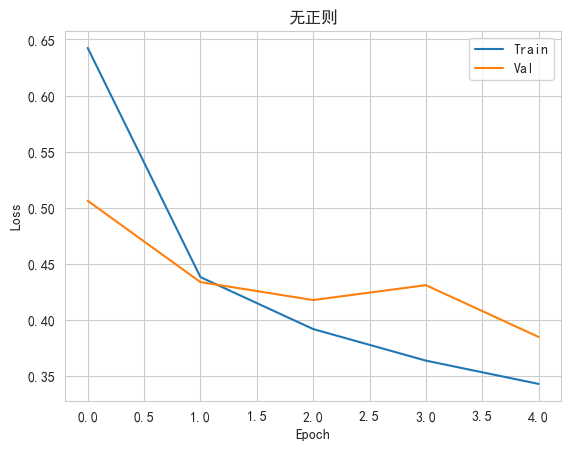

[权重衰减 L2] Epoch 1 | Train Loss: 0.6441 | Val Loss: 0.4974
[权重衰减 L2] Epoch 2 | Train Loss: 0.4397 | Val Loss: 0.4462
[权重衰减 L2] Epoch 3 | Train Loss: 0.3947 | Val Loss: 0.4219
[权重衰减 L2] Epoch 4 | Train Loss: 0.3675 | Val Loss: 0.4128
[权重衰减 L2] Epoch 5 | Train Loss: 0.3460 | Val Loss: 0.3764


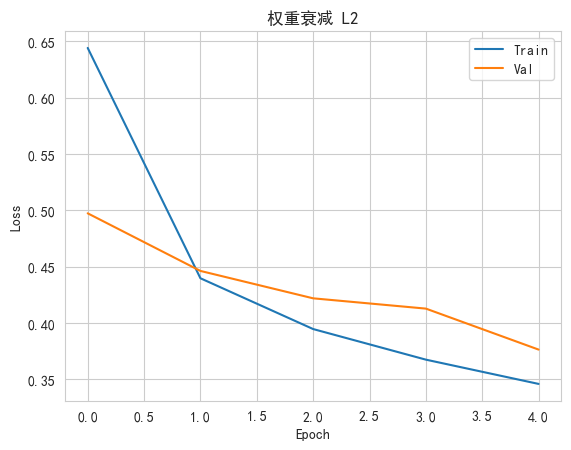

[Dropout] Epoch 1 | Train Loss: 0.6593 | Val Loss: 0.5068
[Dropout] Epoch 2 | Train Loss: 0.4509 | Val Loss: 0.4344
[Dropout] Epoch 3 | Train Loss: 0.4039 | Val Loss: 0.4379
[Dropout] Epoch 4 | Train Loss: 0.3779 | Val Loss: 0.4263
[Dropout] Epoch 5 | Train Loss: 0.3581 | Val Loss: 0.3966


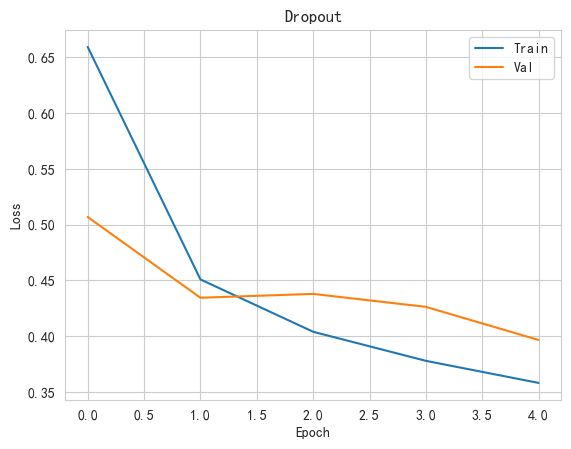

In [13]:
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei'] 

# 先重新定义基础函数，确保全局可用
def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=device))

def softmax(x):
    max_x = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - max_x)
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

def cross_entropy(logits, labels):
    probs = softmax(logits)
    one_hot = torch.zeros_like(probs)
    one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
    return -torch.mean(torch.sum(one_hot * torch.log(probs + 1e-8), dim=1))

def sgd_step(params, lr):
    with torch.no_grad():
        for p in params:
            if p.grad is not None:
                p -= lr * p.grad

def sgd_weight_decay(params, lr, wd):
    with torch.no_grad():
        for p in params:
            if p.grad is not None:
                p *= (1 - lr * wd)
                p -= lr * p.grad

def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = torch.rand_like(X) > dropout
    return X * mask / (1 - dropout)

# 超参数
n_in, n_hid, n_out = 784, 256, 10
lr = 0.1
epochs = 5
wd = 1e-4
dropout = 0.2

# 前向传播（带Dropout）
def forward_reg(x, W1, b1, W2, b2, is_training=True):
    x = x.view(x.shape[0], -1)
    h = relu(x @ W1 + b1)
    h = dropout_layer(h, dropout, is_training)
    logits = h @ W2 + b2
    return logits

# 训练函数（已修复所有bug）
def train_and_plot(title, use_wd=False, use_dropout=False):
    # 每次都重新初始化参数
    W1 = torch.randn(n_in, n_hid, device=device) * 0.01
    b1 = torch.zeros(n_hid, device=device)
    W2 = torch.randn(n_hid, n_out, device=device) * 0.01
    b2 = torch.zeros(n_out, device=device)
    
    W1.requires_grad_(True)
    b1.requires_grad_(True)
    W2.requires_grad_(True)
    b2.requires_grad_(True)
    
    params = [W1, b1, W2, b2]
    
    tr_loss, val_loss = [], []
    
    for epoch in range(epochs):
        total_tr = 0.0
        
        # 训练阶段
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            
            # 梯度清零（关键修复）
            for p in params:
                if p.grad is not None:
                    p.grad.zero_()
            
            logits = forward_reg(X, W1, b1, W2, b2, is_training=use_dropout)
            loss = cross_entropy(logits, y)
            loss.backward()
            
            # 更新
            if use_wd:
                sgd_weight_decay(params, lr, wd)
            else:
                sgd_step(params, lr)
            
            total_tr += loss.item()
        
        tr_loss.append(total_tr / len(train_loader))
        
        # 验证阶段
        total_val = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                logits = forward_reg(X, W1, b1, W2, b2, is_training=False)
                loss = cross_entropy(logits, y)
                total_val += loss.item()
        val_loss.append(total_val / len(test_loader))
        
        print(f"[{title}] Epoch {epoch+1} | Train Loss: {tr_loss[-1]:.4f} | Val Loss: {val_loss[-1]:.4f}")
    
    # 画图
    plt.plot(tr_loss, label="Train")
    plt.plot(val_loss, label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

train_and_plot("无正则", use_wd=False, use_dropout=False)
train_and_plot("权重衰减 L2", use_wd=True, use_dropout=False)
train_and_plot("Dropout", use_wd=False, use_dropout=True)

4.1 理论计算题

1）梯度消失 / 梯度爆炸（矩阵视角）
$$
\frac{\partial L}{\partial h^t}
= \frac{\partial L}{\partial h^d}
\;\prod_{i=t}^{d-1}\frac{\partial h^{i+1}}{\partial h^i}
$$

$$
\frac{\partial h^{i+1}}{\partial h^i} = W_{i+1}^T \,\sigma'(z^i)
$$

$$
\prod_{i}\|W_i^T\,\sigma'(z^i)\| > 1 \quad(\text{爆炸})
$$

$$
\prod_{i}\|W_i^T\,\sigma'(z^i)\| < 1 \quad(\text{消失})
$$

2）ReLU 缓解梯度消失原因
$$
\text{ReLU}(z) = \max(0,z)
$$

$$
\text{ReLU}'(z)=
\begin{cases}
1, & z>0\\
0, & z\le 0
\end{cases}
$$

4.2 深层网络：梯度消失 / 爆炸 + 初始化对比

4.2.1 20 层全连接网络

In [14]:
import torch.nn as nn

def build_deep_net(act=nn.Sigmoid, init_std=1.0):
    layers = []
    in_dim = 256
    for _ in range(20):
        linear = nn.Linear(in_dim, 256)
        nn.init.normal_(linear.weight, mean=0.0, std=init_std)
        nn.init.zeros_(linear.bias)
        layers.append(linear)
        layers.append(act())
    net = nn.Sequential(*layers).to(device)
    return net

# 随机输入
x = torch.randn(32, 256, device=device)

4.2.2 Sigmoid + 普通初始化 → 梯度消失

In [15]:
net_sig = build_deep_net(act=nn.Sigmoid, init_std=1.0)
y = net_sig(x).sum()
y.backward()

print("Sigmoid + std=1 梯度范数：")
for i, layer in enumerate(net_sig):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        print(f"Layer {i//2}: {grad_norm:.8f}")

Sigmoid + std=1 梯度范数：
Layer 0: 6350.66845703
Layer 1: 4503.37939453
Layer 2: 3295.51684570
Layer 3: 2855.04345703
Layer 4: 2191.03320312
Layer 5: 1795.96350098
Layer 6: 1726.80310059
Layer 7: 1124.91967773
Layer 8: 862.28735352
Layer 9: 678.08044434
Layer 10: 529.34313965
Layer 11: 493.68603516
Layer 12: 387.89019775
Layer 13: 324.47198486
Layer 14: 244.51167297
Layer 15: 252.36512756
Layer 16: 222.74198914
Layer 17: 221.47100830
Layer 18: 282.68991089
Layer 19: 313.99569702


4.2.3 ReLU + 大初始化 → 梯度爆炸（NaN）

In [16]:
net_relu_big = build_deep_net(act=nn.ReLU, init_std=10.0)
y = net_relu_big(x).sum()
y.backward()

print("\nReLU + std=10 梯度范数：")
for i, layer in enumerate(net_relu_big):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        print(f"Layer {i//2}: {grad_norm:.8f}")


ReLU + std=10 梯度范数：
Layer 0: nan
Layer 1: inf
Layer 2: inf
Layer 3: inf
Layer 4: inf
Layer 5: inf
Layer 6: inf
Layer 7: inf
Layer 8: inf
Layer 9: inf
Layer 10: inf
Layer 11: inf
Layer 12: inf
Layer 13: inf
Layer 14: inf
Layer 15: inf
Layer 16: inf
Layer 17: inf
Layer 18: inf
Layer 19: nan


4.2.4 Xavier + ReLU → 梯度稳定

In [17]:
def build_xavier_relu():
    layers = []
    in_dim = 256
    for _ in range(20):
        linear = nn.Linear(in_dim, 256)
        nn.init.xavier_uniform_(linear.weight)
        nn.init.zeros_(linear.bias)
        layers.append(linear)
        layers.append(nn.ReLU())
    net = nn.Sequential(*layers).to(device)
    return net

net_xav = build_xavier_relu()
y = net_xav(x).sum()
y.backward()

print("\nXavier + ReLU 梯度范数：")
for i, layer in enumerate(net_xav):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        print(f"Layer {i//2}: {grad_norm:.8f}")


Xavier + ReLU 梯度范数：
Layer 0: 4.52618742
Layer 1: 6.48192644
Layer 2: 7.50227356
Layer 3: 9.01639366
Layer 4: 9.59280968
Layer 5: 9.94085312
Layer 6: 10.37423420
Layer 7: 10.30967045
Layer 8: 12.40467644
Layer 9: 13.59555435
Layer 10: 13.25807762
Layer 11: 13.64559841
Layer 12: 14.73667622
Layer 13: 14.88330364
Layer 14: 14.45298576
Layer 15: 13.32433605
Layer 16: 13.06907463
Layer 17: 11.95514774
Layer 18: 10.64747047
Layer 19: 7.58292055


5.1 理论计算题：协变量偏移 vs 标签偏移

$$
p_{\text{train}}(x) \ne p_{\text{test}}(x),\quad
p_{\text{train}}(y|x) = p_{\text{test}}(y|x)
$$

$$
p_{\text{train}}(y) \ne p_{\text{test}}(y),\quad
p_{\text{train}}(x|y) = p_{\text{test}}(x|y)
$$

5.2 协变量偏移 + 权重修正

5.2.1 构造偏移数据

In [18]:
np.random.seed(0)
# 训练集 P: N(-1,1)
n_train = 1000
x_train = np.random.normal(-1, 1, n_train)
y_train = 2 * x_train + np.random.normal(0, 0.1, n_train)

# 测试集 Q: N(2,1)
n_test = 500
x_test = np.random.normal(2, 1, n_test)
y_test = 2 * x_test + np.random.normal(0, 0.1, n_test)

# 转 Tensor
x_train = torch.tensor(x_train, dtype=torch.float32).unsqueeze(1).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
x_test = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

5.2.2 基线线性回归

In [19]:
def linear_regression(x, w, b):
    return x @ w + b

# 训练
w = torch.randn(1,1, device=device, requires_grad=True)
b = torch.zeros(1, device=device, requires_grad=True)
opt = torch.optim.SGD([w,b], lr=0.01)
epochs=200

for _ in range(epochs):
    y_pred = linear_regression(x_train, w, b)
    loss = torch.mean((y_pred - y_train)**2)
    loss.backward()
    opt.step()
    opt.zero_grad()

# 测试 MSE
with torch.no_grad():
    y_pred_test = linear_regression(x_test, w, b)
    mse_baseline = torch.mean((y_pred_test - y_test)**2).item()
print(f"基线 MSE: {mse_baseline:.4f}")

基线 MSE: 0.0613


5.2.3 逻辑回归求权重

In [20]:
# 混合数据：训练=0，测试=1
X_all = torch.cat([x_train, x_test])
Y_all = torch.cat([torch.zeros_like(x_train), torch.ones_like(x_test)])

# 逻辑回归
w_cls = torch.randn(1,1, device=device, requires_grad=True)
b_cls = torch.zeros(1, device=device, requires_grad=True)
opt_cls = torch.optim.SGD([w_cls, b_cls], lr=0.01)

def sigmoid(x):
    return 1/(1+torch.exp(-x))

for _ in range(epochs):
    logit = X_all @ w_cls + b_cls
    prob = sigmoid(logit)
    loss = -torch.mean(Y_all*torch.log(prob+1e-8)+(1-Y_all)*torch.log(1-prob+1e-8))
    loss.backward()
    opt_cls.step()
    opt_cls.zero_grad()

# 计算权重 w_i ∝ P(test|x)/P(train|x)
with torch.no_grad():
    prob_test = sigmoid(x_train @ w_cls + b_cls)
    prob_train = 1 - prob_test
    weights = prob_test / prob_train
    weights = weights / weights.mean()  # 归一化

5.2.4 加权最小二乘

In [21]:
w_w = torch.randn(1,1, device=device, requires_grad=True)
b_w = torch.zeros(1, device=device, requires_grad=True)
opt_w = torch.optim.SGD([w_w, b_w], lr=0.01)

for _ in range(epochs):
    y_pred = linear_regression(x_train, w_w, b_w)
    loss = torch.mean(weights * (y_pred - y_train)**2)
    loss.backward()
    opt_w.step()
    opt_w.zero_grad()

# 测试
with torch.no_grad():
    y_pred_test_w = linear_regression(x_test, w_w, b_w)
    mse_weighted = torch.mean((y_pred_test_w - y_test)**2).item()
print(f"加权校正 MSE: {mse_weighted:.4f}")

加权校正 MSE: 0.0174
